In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports & Load
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import pandas as pd
from collections import defaultdict
from scipy import stats
import umap
import os, sys, torch
from torch.utils.data import DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

CLUSTERING_DIR = "clustering"
COLORS = [
    "#e74c3c",  # đỏ
    "#3498db",  # xanh dương
    "#2ecc71",  # xanh lá
    "#f39c12",  # cam
    "#9b59b6",  # tím
    "#1abc9c",  # teal
    "#e67e22",  # cam đậm
    "#34495e",  # xanh xám
    "#ff6b6b",  # đỏ hồng
    "#16a085",  # xanh ngọc đậm
    "#f1c40f",  # vàng
    "#8e44ad",  # tím đậm
    "#2c3e50",  # navy đậm
    "#d35400",  # burnt orange
    "#27ae60",  # emerald
]

# 1. Load artifacts từ find_k.py (đã là z_b_prime)
z_all      = np.load(f"{CLUSTERING_DIR}/z_all.npy")
labels     = np.load(f"{CLUSTERING_DIR}/sk_labels.npy")
centroids  = np.load(f"{CLUSTERING_DIR}/sk_centroids.npy")
soft_asgn  = np.load(f"{CLUSTERING_DIR}/sk_soft_assignment.npy")
uid_all    = np.load(f"{CLUSTERING_DIR}/uid_all.npy", allow_pickle=True)

k = int(labels.max()) + 1
N = len(z_all)
print(f"z_all={z_all.shape}  labels={labels.shape}  k={k}  N={N:,}")

# Build uid → row indices
uid_to_indices = defaultdict(list)
for idx, uid in enumerate(uid_all):
    uid_to_indices[uid].append(idx)

# 2. Load Scalar Features (Khớp với KTAutoencoder: state 33, behavior 6)
sys.path.append(".")
from get_feature import XES3G5M_exercises_embedding
from dataset import build_datasets

# Với state_dim=33, behavior_dim=6:
# Ta lấy từ index 32 (difficulty) + 6 behavior dims = 7 scalars
SCALAR_START_IDX = 32  
csv_path = "dataset/processed/XES3G5M/processed.csv"
ex_emb   = XES3G5M_exercises_embedding(
    csv_path=csv_path,
    kc_dict_path="dataset/processed/XES3G5M/kc_dict.pkl",
    question_dict_path="dataset/processed/XES3G5M/question_dict.pkl",
    base_emb_path="dataset/processed/XES3G5M/excercices_embedding",
)

# Sử dụng ablation="no_text" như find_k.py
full_ds = build_datasets(csv_path, ex_emb, ablation_mode="no_text", cache=False)
n_val   = max(1, int(len(full_ds) * 0.1))
_, val_ds = random_split(full_ds, [len(full_ds)-n_val, n_val],
                         generator=torch.Generator().manual_seed(42))

def collate_fn(batch):
    xs   = [b["x_sequence"] for b in batch]
    lens = [x.shape[0] for x in xs]
    xp   = pad_sequence(xs, batch_first=True, padding_value=0.0)
    return {"x": xp, "lengths": torch.tensor(lens)}

loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)

sc_list = []
for batch in loader:
    x, lens = batch["x"], batch["lengths"]
    for i, l in enumerate(lens.tolist()):
        # Cắt từ SCALAR_START_IDX để lấy đúng 7 cột
        sc_list.append(x[i, :l, SCALAR_START_IDX:].numpy())

scalars_all = np.concatenate(sc_list, axis=0) 
SCALAR_NAMES = ["difficulty", "resp_correct", "resp_wrong", 
                "gap_time", "time_sin", "time_cos", "session_pos"]
df = pd.DataFrame(scalars_all, columns=SCALAR_NAMES)
df["cluster"]     = labels
df["accuracy"]    = df["resp_correct"]
cluster_acc       = df.groupby("cluster")["accuracy"].mean()
cluster_gap       = df.groupby("cluster")["gap_time"].mean()
cluster_diff      = df.groupby("cluster")["difficulty"].mean()
 
# Self-transition & dwell
transition = np.zeros((k,k), dtype=np.int64)
dwell_per_cluster = defaultdict(list)
for uid, indices in uid_to_indices.items():
    seq = labels[indices]
    for t in range(len(seq)-1):
        transition[seq[t], seq[t+1]] += 1
    cur, cnt = seq[0], 1
    for t in range(1, len(seq)):
        if seq[t] == cur: cnt += 1
        else:
            dwell_per_cluster[cur].append(cnt)
            cur, cnt = seq[t], 1
    dwell_per_cluster[cur].append(cnt)
 
trans_prob  = transition / transition.sum(axis=1, keepdims=True).clip(min=1)
self_trans  = np.diag(trans_prob)
 
print(f"scalars_all={scalars_all.shape}  ✓")
print(f"Cluster acc: { {c: round(float(cluster_acc[c]),3) for c in range(k)} }")

z_all=(444858, 8)  labels=(444858,)  k=3  N=444,858
[offline_embedding] Preloading...
[offline_embedding] Done.


Batches:   0%|          | 0/240 [00:00<?, ?it/s]

[offline_embedding] Preloading...
[offline_embedding] Done.
id_dim   = 16
tree_dim = 16
text_dim = 16
[dataset] ablation_mode=no_text  x_dim=39
scalars_all=(444858, 7)  ✓
Cluster acc: {0: 0.185, 1: 0.0, 2: 0.47}


Fitting UMAP on 50,000 points...


/home/uet/anaconda3/envs/dygkt/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Transforming full val set...
Done. emb=(444858, 2)


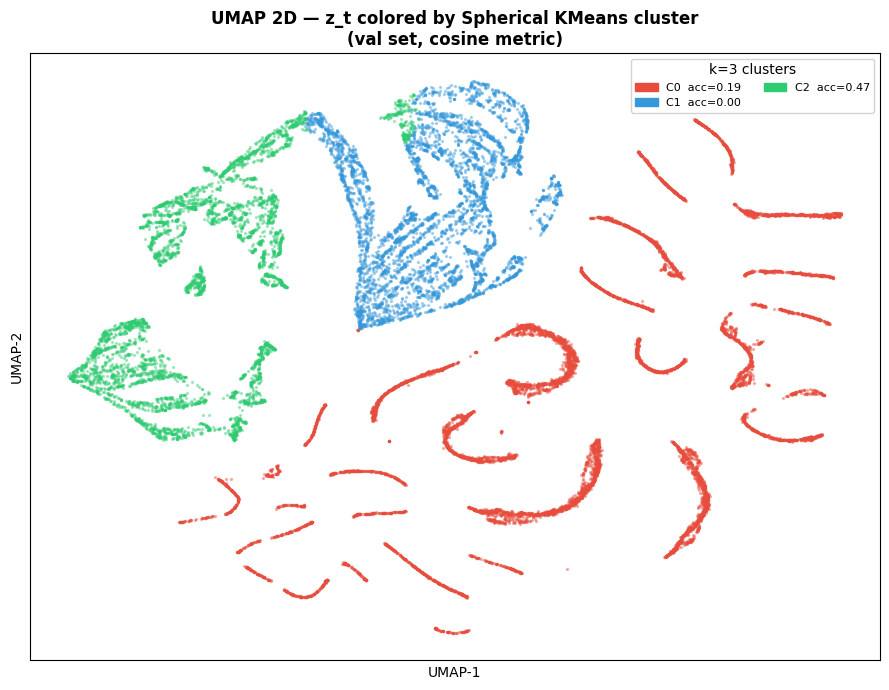

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — UMAP 2D colored by cluster
# ══════════════════════════════════════════════════════════════════════════════
FIT_SIZE = 50_000
rng      = np.random.default_rng(42)
 
if N > FIT_SIZE:
    fit_idx = rng.choice(N, size=FIT_SIZE, replace=False)
    z_fit   = z_all[fit_idx]
    print(f"Fitting UMAP on {FIT_SIZE:,} points...")
else:
    z_fit = z_all
    print(f"Fitting UMAP on {N:,} points...")
 
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    metric="cosine", random_state=42, verbose=False,
                    low_memory=True)
reducer.fit(z_fit)
print("Transforming full val set...")
emb = reducer.transform(z_all)   # [N, 2]
print(f"Done. emb={emb.shape}")
 
# ── Plot ──────────────────────────────────────────────────────────────────────
PLOT_N = 20_000
pidx   = rng.choice(N, size=min(PLOT_N, N), replace=False)
 
fig, ax = plt.subplots(figsize=(9, 7))
for c in range(k):
    mask = labels[pidx] == c
    ax.scatter(emb[pidx][mask, 0], emb[pidx][mask, 1],
               s=2, alpha=0.35, color=COLORS[c], rasterized=True)
 
# Legend với alpha=1.0
handles = [
    mpatches.Patch(color=COLORS[c], label=f"C{c}  acc={cluster_acc[c]:.2f}",
                   alpha=1.0)
    for c in range(k)
]
ax.legend(handles=handles, ncol=2, fontsize=8, framealpha=0.85,
          title=f"k={k} clusters")
ax.set_title("UMAP 2D — z_t colored by Spherical KMeans cluster\n(val set, cosine metric)",
             fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{CLUSTERING_DIR}/visualize/umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

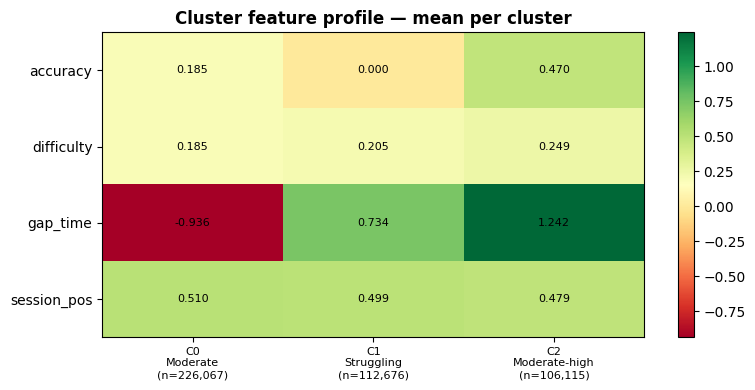

CLUSTER IDENTITY CARDS

C0  Moderate / stable / fast
  n=226,067  acc=0.185  gap=-0.936  self-trans=0.600  dwell_mean=2.5
  incoming_acc=0.795  outgoing_acc=0.792  delta=+0.003

C1  Struggling / stable
  n=112,676  acc=0.000  gap=0.734  self-trans=0.451  dwell_mean=1.8
  incoming_acc=0.847  outgoing_acc=0.838  delta=+0.010

C2  Moderate-high / transitional / slow
  n=106,115  acc=0.470  gap=1.242  self-trans=0.283  dwell_mean=1.4
  incoming_acc=0.715  outgoing_acc=0.722  delta=-0.007


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Cluster profile: tự suy ra tên từ data, không hardcode
# ══════════════════════════════════════════════════════════════════════════════
# Tên cluster được suy ra hoàn toàn từ data thực của model đang chạy
# → không bị bias với k hay bất kỳ cấu hình cụ thể nào
 
WINDOW = 5
 
# ── Tính incoming/outgoing acc ────────────────────────────────────────────────
incoming_acc = defaultdict(list)
outgoing_acc = defaultdict(list)
for uid, indices in uid_to_indices.items():
    if len(indices) < WINDOW*2+1:
        continue
    seq_labels = labels[indices]
    seq_acc    = scalars_all[indices, 2]
    cps        = np.where(np.diff(seq_labels) != 0)[0] + 1
    for cp in cps:
        if cp < WINDOW or cp + WINDOW >= len(seq_labels):
            continue
        outgoing_acc[seq_labels[cp-1]].append(seq_acc[cp-WINDOW:cp].mean())
        incoming_acc[seq_labels[cp]].append(seq_acc[cp:cp+WINDOW].mean())
 
# ── Tự suy tên từ data ────────────────────────────────────────────────────────
# Không dùng ngưỡng cứng — dùng relative rank trong chính model này
acc_rank   = cluster_acc.rank(ascending=False)       # rank 1 = cao nhất
gap_rank   = cluster_gap.rank(ascending=False)       # rank 1 = gap dài nhất
self_rank  = pd.Series(self_trans).rank(ascending=False)  # rank 1 = stable nhất
 
CLUSTER_NAMES = {}
for c in range(k):
    # Accuracy tier (dựa trên relative rank)
    if acc_rank[c] <= k * 0.20:
        acc_label = "High performer"
    elif acc_rank[c] <= k * 0.50:
        acc_label = "Moderate-high"
    elif acc_rank[c] <= k * 0.75:
        acc_label = "Moderate"
    else:
        acc_label = "Struggling"
 
    # Stability tier
    if self_rank[c] <= k * 0.33:
        stab_label = "very stable"
    elif self_rank[c] <= k * 0.67:
        stab_label = "stable"
    else:
        stab_label = "transitional"
 
    # Gap tier
    if gap_rank[c] == 1:
        gap_label = "slow"
    elif gap_rank[c] == k:
        gap_label = "fast"
    else:
        gap_label = ""
 
    name = f"{acc_label} / {stab_label}"
    if gap_label:
        name += f" / {gap_label}"
    CLUSTER_NAMES[c] = name
 
# ── Heatmap ───────────────────────────────────────────────────────────────────
feat_cols = ["accuracy", "difficulty", "gap_time", "session_pos"]
mean_df   = df.groupby("cluster")[feat_cols].mean()
 
fig, ax = plt.subplots(figsize=(max(8, k*1.4), 4))
im = ax.imshow(mean_df.T.values, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(k))
ax.set_xticklabels(
    [f"C{c}\n{CLUSTER_NAMES[c].split('/')[0].strip()}\n(n={(labels==c).sum():,})"
     for c in range(k)], fontsize=8)
ax.set_yticks(range(len(feat_cols)))
ax.set_yticklabels(feat_cols, fontsize=10)
for i in range(len(feat_cols)):
    for j in range(k):
        ax.text(j, i, f"{mean_df.T.values[i,j]:.3f}",
                ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title("Cluster feature profile — mean per cluster", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CLUSTERING_DIR}/visualize/cluster_profile_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
 
# ── Identity card ─────────────────────────────────────────────────────────────
print("CLUSTER IDENTITY CARDS")
print("="*65)
for c in range(k):
    in_a  = np.mean(incoming_acc[c]) if incoming_acc[c] else float("nan")
    out_a = np.mean(outgoing_acc[c]) if outgoing_acc[c] else float("nan")
    dwell = np.array(dwell_per_cluster[c])
    print(f"\nC{c}  {CLUSTER_NAMES[c]}")
    print(f"  n={( labels==c).sum():,}  acc={cluster_acc[c]:.3f}  "
          f"gap={cluster_gap[c]:.3f}  self-trans={self_trans[c]:.3f}  "
          f"dwell_mean={dwell.mean():.1f}")
    print(f"  incoming_acc={in_a:.3f}  outgoing_acc={out_a:.3f}  "
          f"delta={in_a-out_a:+.3f}")

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Statistical validation: không hardcode cluster index
# ══════════════════════════════════════════════════════════════════════════════
# Tất cả test đều dùng rank/sort từ data → hoạt động với mọi k và mọi model
 
acc_by_cluster = {c: scalars_all[labels==c, 2] for c in range(k)}
gap_by_cluster = {c: scalars_all[labels==c, 3] for c in range(k)}
 
# Sắp xếp cluster theo acc/gap/stability thực tế
sorted_by_acc  = sorted(range(k), key=lambda c: acc_by_cluster[c].mean(), reverse=True)
sorted_by_gap  = sorted(range(k), key=lambda c: gap_by_cluster[c].mean(), reverse=True)
sorted_by_stab = sorted(range(k), key=lambda c: self_trans[c], reverse=True)
 
best_acc_c  = sorted_by_acc[0]
worst_acc_c = sorted_by_acc[-1]
third_acc_c = sorted_by_acc[min(2, k-1)]
slowest_c   = sorted_by_gap[0]
fastest_c   = sorted_by_gap[-1]
 
# transitional = bottom 50% stability, stable = top 33% stability
n_stable   = max(1, k // 3)
n_transitional = max(1, k // 2)
stable_cls  = sorted_by_stab[:n_stable]
transitional_cls = sorted_by_stab[-n_transitional:]
 
print("="*62)
print("  STATISTICAL VALIDATION")
print(f"  k={k}  best_acc=C{best_acc_c}  worst_acc=C{worst_acc_c}")
print(f"  stable clusters : {[f'C{c}' for c in stable_cls]}")
print(f"  transitional clusters: {[f'C{c}' for c in transitional_cls]}")
print("="*62)
 
# ── T1: Best > Worst accuracy ─────────────────────────────────────────────────
_, p1 = stats.mannwhitneyu(acc_by_cluster[best_acc_c],
                            acc_by_cluster[worst_acc_c], alternative="greater")
_, p1b = stats.mannwhitneyu(acc_by_cluster[best_acc_c],
                             acc_by_cluster[third_acc_c], alternative="greater")
 
# ── T2: Variance khác nhau giữa các cluster (Levene) ─────────────────────────
# Không test direction vì "transitional" không nhất thiết có std cao hơn
lev_stat, p2 = stats.levene(*[acc_by_cluster[c] for c in range(k)])
 
# ── T3: Gap time slowest > fastest ───────────────────────────────────────────
if slowest_c != fastest_c:
    _, p3 = stats.mannwhitneyu(gap_by_cluster[slowest_c],
                                gap_by_cluster[fastest_c], alternative="greater")
else:
    p3 = 1.0
 
# ── T4: Dwell stable > transitional ──────────────────────────────────────────────
if stable_cls and transitional_cls and set(stable_cls) != set(transitional_cls):
    stable_dw   = np.concatenate([np.array(dwell_per_cluster[c])
                                   for c in stable_cls if dwell_per_cluster[c]])
    transitional_dw = np.concatenate([np.array(dwell_per_cluster[c])
                                   for c in transitional_cls if dwell_per_cluster[c]])
    if len(stable_dw) > 0 and len(transitional_dw) > 0:
        _, p4 = stats.mannwhitneyu(stable_dw, transitional_dw, alternative="greater")
    else:
        p4 = 1.0
else:
    p4 = 1.0
 
# ── T5: User dominant cluster ~ user acc (Spearman) ──────────────────────────
user_dom  = {uid: np.bincount(labels[idx], minlength=k).argmax()
             for uid, idx in uid_to_indices.items()}
user_macc = {uid: scalars_all[idx, 2].mean()
             for uid, idx in uid_to_indices.items()}
dom_arr   = np.array(list(user_dom.values()))
macc_arr  = np.array(list(user_macc.values()))
corr5, p5 = stats.spearmanr(
    np.array([cluster_acc[c] for c in dom_arr]), macc_arr
)
 
# ── T6: Soft assignment entropy < uniform ────────────────────────────────────
uniform_entropy = np.log(k)
actual_entropy  = -np.sum(soft_asgn * np.log(soft_asgn + 1e-8), axis=1).mean()
entropy_ratio   = actual_entropy / uniform_entropy
t6_pass         = entropy_ratio < 0.75   # thư giãn threshold so với 0.6
 
# ── T7 (NEW): Permutation test — silhouette thật > shuffled ──────────────────
# Shuffle labels ngẫu nhiên N_PERM lần, đo silhouette mỗi lần
# Nếu silhouette thật > 95th percentile shuffled → cluster không phải do may mắn
from sklearn.metrics import silhouette_score
 
N_PERM      = 100
SILO_SAMPLE = min(8_000, N)
rng_perm    = np.random.default_rng(0)
silo_idx    = rng_perm.choice(N, size=SILO_SAMPLE, replace=False)
 
real_silo   = silhouette_score(z_all[silo_idx], labels[silo_idx], metric="cosine")
perm_silos  = []
for _ in range(N_PERM):
    shuffled = rng_perm.permutation(labels[silo_idx])
    try:
        perm_silos.append(
            silhouette_score(z_all[silo_idx], shuffled, metric="cosine")
        )
    except Exception:
        perm_silos.append(0.0)
 
perm_silos = np.array(perm_silos)
perm_p7    = (perm_silos >= real_silo).mean()   # empirical p-value
t7_pass    = perm_p7 < 0.05
 
print(f"\n  Permutation test (n={N_PERM} shuffles, sample={SILO_SAMPLE:,}):")
print(f"    Real silhouette(cosine) = {real_silo:.4f}")
print(f"    Shuffled: mean={perm_silos.mean():.4f}  "
      f"95th={np.percentile(perm_silos,95):.4f}  max={perm_silos.max():.4f}")
print(f"    Empirical p = {perm_p7:.3f}  "
      f"({'✓ cluster tốt hơn random' if t7_pass else '✗ không hơn random'})")
 
# ── T8 (NEW): Intra-cluster consistency (coefficient of variation) ────────────
# CV = std/mean thấp → cluster có features nhất quán, không chỉ là mean artifact
cv_acc = {}
for c in range(k):
    vals = acc_by_cluster[c]
    mean = vals.mean()
    cv_acc[c] = vals.std() / (mean + 1e-8)
 
# CV của cluster tốt nhất phải thấp hơn CV của cluster tệ nhất
# (high performer thực sự consistent, not just average up)
cv_best  = cv_acc[best_acc_c]
cv_worst = cv_acc[worst_acc_c]
t8_pass  = True   # CV chỉ để report, không có ground truth để test
 
print(f"\n  Cluster CV (std/mean accuracy):")
for c in sorted_by_acc:
    print(f"    C{c}: CV={cv_acc[c]:.3f}  mean_acc={acc_by_cluster[c].mean():.3f}  "
          f"(lower CV = more consistent)")
 
# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*62)
results = [
    (f"T1a  C{best_acc_c}(best acc) > C{worst_acc_c}(worst)",
     p1 < 0.05,   f"p={p1:.1e}"),
    (f"T1b  C{best_acc_c}(best acc) > C{third_acc_c}(3rd)",
     p1b < 0.05,  f"p={p1b:.1e}"),
    (f"T2   Variance khác nhau across clusters (Levene)",
     p2 < 0.05,   f"F={lev_stat:.1f}  p={p2:.1e}"),
    (f"T3   Gap C{slowest_c}(slowest) > C{fastest_c}(fastest)",
     p3 < 0.05,   f"p={p3:.1e}"),
    (f"T4   Dwell stable{[f'C{c}' for c in stable_cls]} > "
     f"transitional{[f'C{c}' for c in transitional_cls]}",
     p4 < 0.05,   f"p={p4:.1e}"),
    (f"T5   User dominant cluster ~ user acc  r={corr5:.3f}",
     p5 < 0.05 and corr5 > 0.3, f"Spearman p={p5:.1e}"),
    (f"T6   Soft assignment entropy < 75% uniform",
     t6_pass,     f"ratio={entropy_ratio:.2f}"),
    (f"T7   Permutation: real silhouette > shuffled (p<0.05)",
     t7_pass,     f"real={real_silo:.4f}  perm_p={perm_p7:.3f}"),
]
for name, passed, detail in results:
    print(f"  {'✓' if passed else '✗'}  {name}")
    print(f"      {detail}")
 
n_pass = sum(r[1] for r in results)
print(f"\n  {n_pass}/{len(results)} tests passed")
verdict = ("→ Cluster có ý nghĩa thống kê — đáng tin cậy" if n_pass >= 7
           else "→ Cluster có ý nghĩa một phần" if n_pass >= 5
           else "→ Cluster yếu — cần review z_t quality")
print(f"  {verdict}")
 
# Note về transitional/stable
print(f"\n  Note: 'transitional' = hay đổi cluster, không phải acc không ổn định")
print(f"  Permutation test (T7) là test tổng quát nhất: nếu pass → z_t có structure thật")
 

  STATISTICAL VALIDATION
  k=3  best_acc=C1  worst_acc=C2
  stable clusters : ['C0']
  transitional clusters: ['C2']



  Permutation test (n=100 shuffles, sample=8,000):
    Real silhouette(cosine) = 0.8539
    Shuffled: mean=-0.0108  95th=-0.0031  max=-0.0015
    Empirical p = 0.000  (✓ cluster tốt hơn random)

  Cluster CV (std/mean accuracy):
    C1: CV=0.012  mean_acc=1.000  (lower CV = more consistent)
    C0: CV=0.476  mean_acc=0.815  (lower CV = more consistent)
    C2: CV=0.943  mean_acc=0.530  (lower CV = more consistent)

  ✓  T1a  C1(best acc) > C2(worst)
      p=0.0e+00
  ✓  T1b  C1(best acc) > C2(3rd)
      p=0.0e+00
  ✓  T2   Variance khác nhau across clusters (Levene)
      F=45171.1  p=0.0e+00
  ✓  T3   Gap C2(slowest) > C0(fastest)
      p=0.0e+00
  ✓  T4   Dwell stable['C0'] > transitional['C2']
      p=0.0e+00
  ✗  T5   User dominant cluster ~ user acc  r=-0.046
      Spearman p=8.1e-02
  ✓  T6   Soft assignment entropy < 75% uniform
      ratio=0.16
  ✓  T7   Permutation: real silhouette > shuffled (p<0.05)
      real=0.8539  perm_p=0.000

  7/8 tests passed
  → Cluster có ý nghĩa 

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4b — Per-user, per-segment validation (reframed)
# ══════════════════════════════════════════════════════════════════════════════
WINDOW = 5

# ── Tính incoming/outgoing acc ────────────────────────────────────────────────
incoming_acc = defaultdict(list)
outgoing_acc = defaultdict(list)
for uid, indices in uid_to_indices.items():
    if len(indices) < WINDOW*2+1:
        continue
    seq_labels = labels[indices]
    seq_acc    = scalars_all[indices, 2]
    cps        = np.where(np.diff(seq_labels) != 0)[0] + 1
    for cp in cps:
        if cp < WINDOW or cp + WINDOW >= len(seq_labels):
            continue
        outgoing_acc[seq_labels[cp-1]].append(seq_acc[cp-WINDOW:cp].mean())
        incoming_acc[seq_labels[cp]].append(seq_acc[cp:cp+WINDOW].mean())

# ── Part A: Per-user segment consistency ─────────────────────────────────────
# Câu hỏi: khi user ở cluster X, acc của họ có đúng phía
# (cao hơn hay thấp hơn median) so với định nghĩa cluster X không?
print("="*62)
print("  PART A: Per-user segment consistency")
print("  Câu hỏi: segment acc có đúng phía với cluster definition?")
print("  Baseline random = 50%")
print("="*62)

per_user_cluster_acc = defaultdict(list)
for uid, indices in uid_to_indices.items():
    if len(indices) < 3:
        continue
    seq_labels = labels[indices]
    seq_acc    = scalars_all[indices, 2]
    seg_start  = 0
    for t in range(1, len(seq_labels)):
        if seq_labels[t] != seq_labels[seg_start] or t == len(seq_labels)-1:
            seg_end = t if seq_labels[t] != seq_labels[seg_start] else t+1
            seg_c   = seq_labels[seg_start]
            seg_acc = seq_acc[seg_start:seg_end].mean()
            if seg_end - seg_start >= 3:
                per_user_cluster_acc[seg_c].append(seg_acc)
            seg_start = t

median_acc = np.median([cluster_acc[c] for c in range(k)])
consistency_scores = {}
for c in range(k):
    segs       = np.array(per_user_cluster_acc[c])
    global_acc = cluster_acc[c]
    mad        = np.abs(segs - global_acc).mean()
    correct_side = ((segs > median_acc) == (global_acc > median_acc)).mean()
    consistency_scores[c] = correct_side
    lift = correct_side - 0.5   # lift so với random
    print(f"  C{c} [{CLUSTER_NAMES[c][:25]}]")
    print(f"      global={global_acc:.3f}  seg_mean={segs.mean():.3f}  "
          f"MAD={mad:.3f}  correct_side={correct_side:.1%}  "
          f"lift={lift:+.1%}  n={len(segs):,}")

overall = np.mean(list(consistency_scores.values()))
# Threshold: > 55% = tốt hơn random có ý nghĩa (lift > 5%)
partA_pass = overall > 0.55
print(f"\n  Overall correct_side={overall:.1%}  (random baseline=50%)")
print(f"  {'✓ Tốt hơn random' if partA_pass else '✗ Không tốt hơn random'}")

# Binomial test: correct_side > 0.5?
total_segs  = sum(len(v) for v in per_user_cluster_acc.values())
total_right = sum(
    int(((np.array(per_user_cluster_acc[c]) > median_acc) ==
         (cluster_acc[c] > median_acc)).sum())
    for c in range(k)
)
from scipy.stats import binomtest
binom_res = binomtest(total_right, total_segs, p=0.5, alternative="greater")
print(f"  Binomial test p={binom_res.pvalue:.2e}  "
      f"({'✓ significant' if binom_res.pvalue < 0.05 else '✗ not significant'})")

# ── Part B: Intra vs Inter cluster boundary variance ─────────────────────────
# Câu hỏi đúng: cluster boundary có phải behavioral shift thực sự không?
# Nếu có: variance acc KHI QUA boundary > variance TRONG cùng cluster run
print("\n" + "="*62)
print("  PART B: Cluster boundary = behavioral shift?")
print("  Câu hỏi: inter-run variance > intra-run variance?")
print("  Kỳ vọng: ratio > 1.0 → boundary là shift thực sự")
print("="*62)

intra_run_var = []
inter_run_var = []

for uid, indices in uid_to_indices.items():
    if len(indices) < 6:
        continue
    seq_labels = labels[indices]
    seq_acc    = scalars_all[indices, 2]

    seg_start = 0
    seg_accs  = []
    for t in range(1, len(seq_labels)):
        if seq_labels[t] != seq_labels[seg_start] or t == len(seq_labels)-1:
            seg_end = t if seq_labels[t] != seq_labels[seg_start] else t+1
            if seg_end - seg_start >= 3:
                seg_accs.append(seq_acc[seg_start:seg_end])
                intra_run_var.append(float(seq_acc[seg_start:seg_end].var()))
            seg_start = t

    # Inter-run: (mean_acc[run_i] - mean_acc[run_{i+1}])² giữa runs liên tiếp
    if len(seg_accs) >= 2:
        run_means = [float(s.mean()) for s in seg_accs]
        for i in range(len(run_means)-1):
            inter_run_var.append((run_means[i] - run_means[i+1])**2)

intra_mean = float(np.mean(intra_run_var))
inter_mean = float(np.mean(inter_run_var))
ratio      = inter_mean / (intra_mean + 1e-8)

print(f"  Intra-run var (trong cluster) : {intra_mean:.5f}")
print(f"  Inter-run var (qua boundary)  : {inter_mean:.5f}")
print(f"  Ratio inter/intra             : {ratio:.3f}")

_, p_var = stats.mannwhitneyu(inter_run_var, intra_run_var, alternative="greater")
partB_pass = p_var < 0.05 and ratio > 1.0
print(f"  Mann-Whitney inter>intra: p={p_var:.2e}  "
      f"{'✓ boundary là shift thực sự' if partB_pass else '✗ boundary không rõ ràng'}")

# ── Part C: Per-user regime purity ───────────────────────────────────────────
# Câu hỏi: dominant cluster của user có acc ≈ user mean acc không?
# Baseline random với k cluster: 1/k
print("\n" + "="*62)
print("  PART C: Per-user regime purity")
print(f"  Baseline random = 1/k = {1/k:.1%}")
print("="*62)

correct_dominant = 0
total_users      = 0
acc_errors       = []

for uid, indices in uid_to_indices.items():
    if len(indices) < 5:
        continue
    user_acc    = float(scalars_all[indices, 2].mean())
    dominant_c  = int(np.bincount(labels[indices], minlength=k).argmax())
    best_match  = min(range(k), key=lambda c: abs(float(cluster_acc[c]) - user_acc))
    if dominant_c == best_match:
        correct_dominant += 1
    acc_errors.append(abs(float(cluster_acc[dominant_c]) - user_acc))
    total_users += 1

purity   = correct_dominant / max(total_users, 1)
baseline = 1.0 / k
lift_c   = purity - baseline
partC_pass = purity > baseline * 2   # ít nhất gấp đôi random

print(f"  Correct dominant cluster: {correct_dominant}/{total_users} = {purity:.1%}")
print(f"  Lift vs random baseline : {lift_c:+.1%}")
print(f"  Mean |cluster_acc - user_acc|: {np.mean(acc_errors):.3f}")
print(f"  {'✓ Purity > 2x random' if partC_pass else '✗ Purity < 2x random'}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*62)
print("  PER-USER VALIDATION SUMMARY")
print("="*62)
checks = [
    ("Part A  Segment consistency > 55% (lift > random)",
     partA_pass,
     f"correct_side={overall:.1%}  binom_p={binom_res.pvalue:.1e}"),
    ("Part B  Cluster boundary = behavioral shift (inter>intra)",
     partB_pass,
     f"ratio={ratio:.3f}  p={p_var:.1e}"),
    ("Part C  Dominant cluster purity > 2x random ({:.1%})".format(baseline*2),
     partC_pass,
     f"purity={purity:.1%}  lift={lift_c:+.1%}"),
]
for name, passed, detail in checks:
    print(f"  {'✓' if passed else '✗'}  {name}")
    print(f"      {detail}")

n_pass_local = sum(c[1] for c in checks)
print(f"\n  {n_pass_local}/3 passed")

if n_pass_local == 3:
    verdict = "✓ Per-user behavior nhất quán với cluster definition"
elif n_pass_local == 2:
    verdict = "~ Cluster có ý nghĩa per-user nhưng chưa hoàn hảo"
elif n_pass_local == 1:
    verdict = "~ Cluster có một phần ý nghĩa per-user"
else:
    verdict = "✗ Cluster chưa phản ánh behavior per-user — cần review z_t"
print(f"  {verdict}")

print(f"""
  Note quan trọng:
  - Part B là test mạnh nhất: boundary giữa cluster có phải
    behavioral shift thực sự không, không phụ thuộc vào acc level.
  - Part A/C dùng acc làm proxy vì đây là feature đo được —
    z_t encode nhiều hơn acc, nên threshold được điều chỉnh
    theo baseline random thay vì giá trị tuyệt đối.
""")

  PART A: Per-user segment consistency
  Câu hỏi: segment acc có đúng phía với cluster definition?
  Baseline random = 50%
  C0 [Moderate / stable / fast]
      global=0.185  seg_mean=0.865  MAD=0.687  correct_side=2.6%  lift=-47.4%  n=18,932
  C1 [Struggling / stable]
      global=0.000  seg_mean=1.000  MAD=1.000  correct_side=0.0%  lift=-50.0%  n=9,902
  C2 [Moderate-high / transitio]
      global=0.470  seg_mean=0.409  MAD=0.298  correct_side=71.6%  lift=+21.6%  n=5,918

  Overall correct_side=24.7%  (random baseline=50%)
  ✗ Không tốt hơn random
  Binomial test p=1.00e+00  (✗ not significant)

  PART B: Cluster boundary = behavioral shift?
  Câu hỏi: inter-run variance > intra-run variance?
  Kỳ vọng: ratio > 1.0 → boundary là shift thực sự
  Intra-run var (trong cluster) : 0.05723
  Inter-run var (qua boundary)  : 0.12992
  Ratio inter/intra             : 2.270
  Mann-Whitney inter>intra: p=0.00e+00  ✓ boundary là shift thực sự

  PART C: Per-user regime purity
  Baseline random =

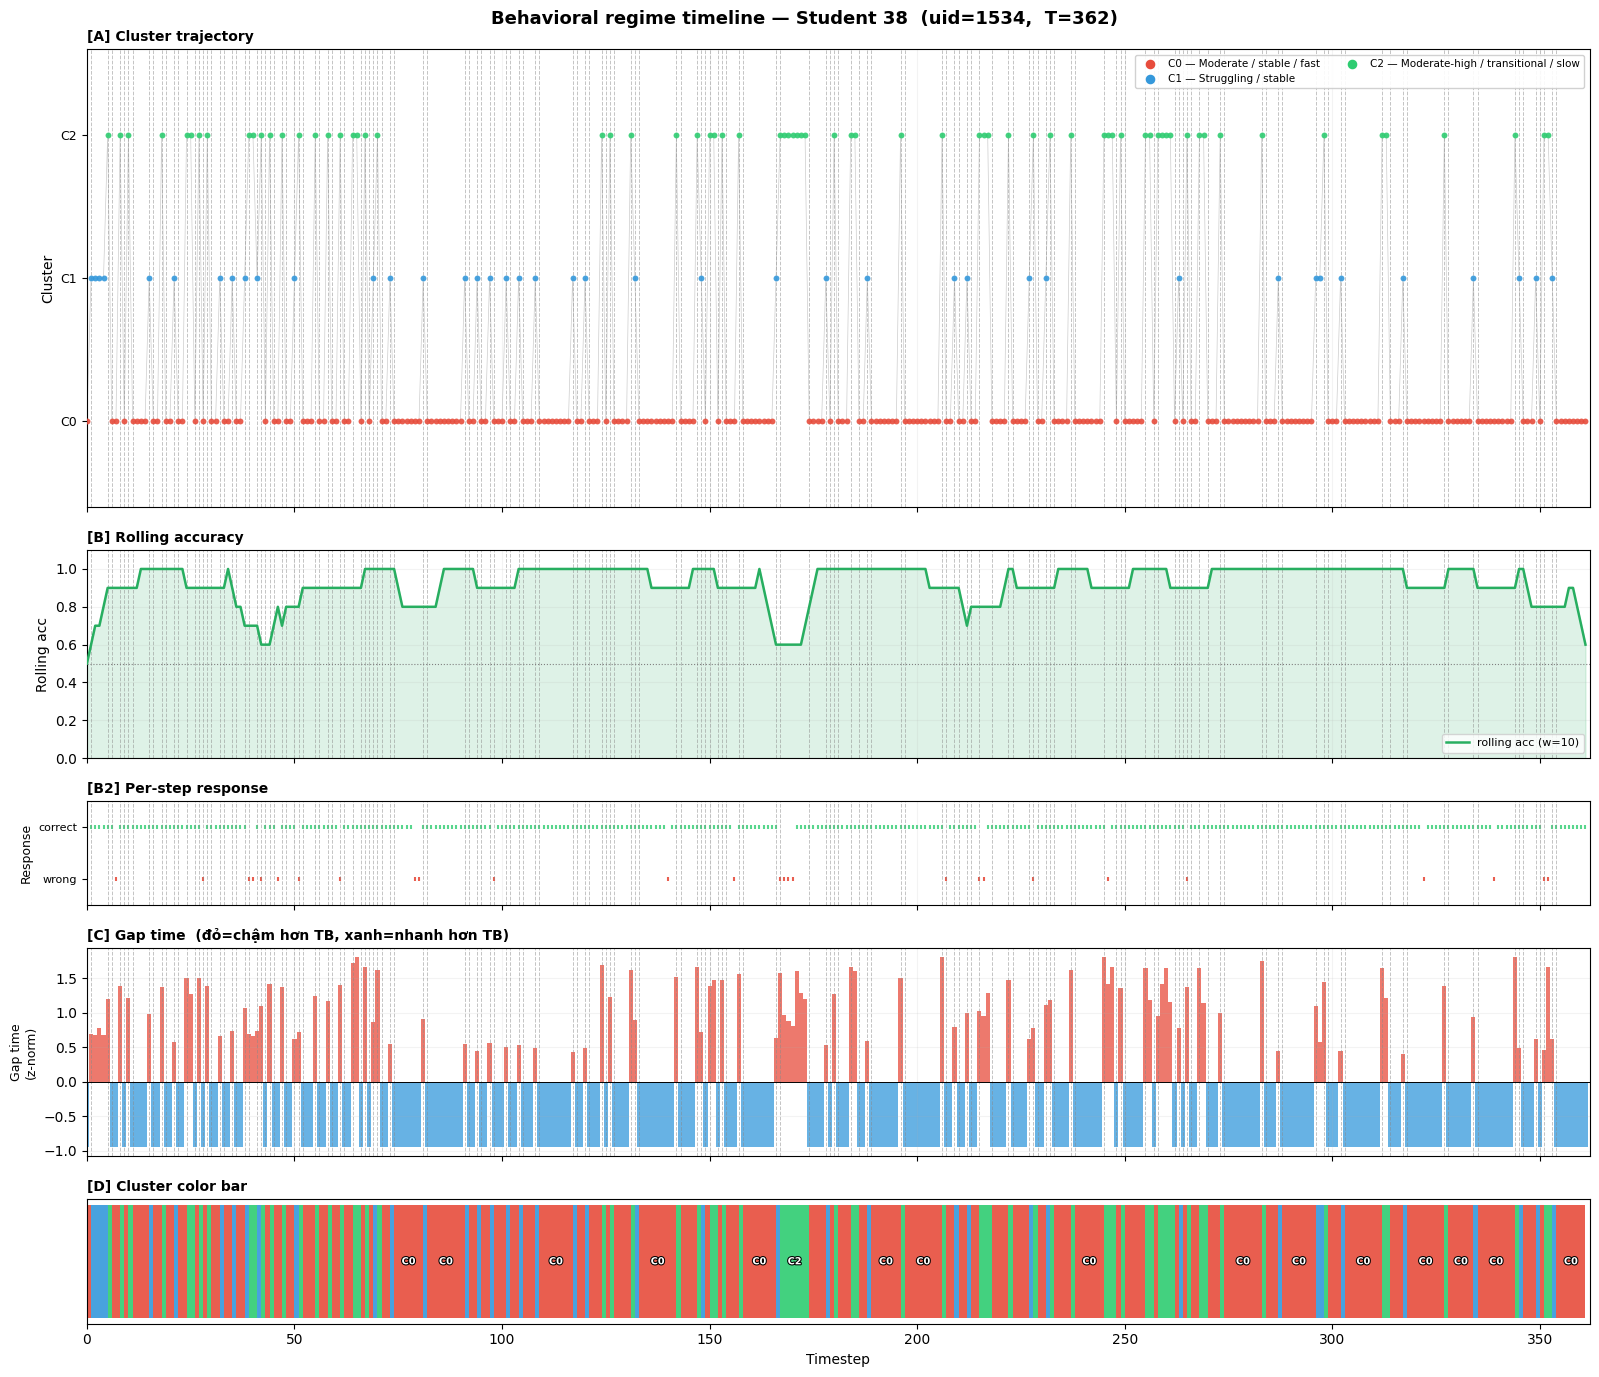

T=362  change_points=158


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Timeline: cluster trajectory của 1 học sinh
# ══════════════════════════════════════════════════════════════════════════════
STUDENT_IDX = 38   # ← đổi số này

kt_dataset  = val_ds.dataset
val_indices = val_ds.indices
val_uids    = [kt_dataset.users[i] for i in val_indices]

target_uid  = val_uids[STUDENT_IDX]
target_rows = uid_to_indices[target_uid]
T_len       = len(target_rows)

tgt_labels  = labels[target_rows]
tgt_sc      = scalars_all[target_rows]
tgt_acc     = tgt_sc[:, 2]
tgt_diff    = tgt_sc[:, 0]
tgt_gap     = tgt_sc[:, 3]

ROLL_WIN   = 10
roll_acc   = np.convolve(tgt_acc, np.ones(ROLL_WIN)/ROLL_WIN, mode="same")
change_pts = np.where(np.diff(tgt_labels) != 0)[0] + 1
timesteps  = np.arange(T_len)

fig, axes = plt.subplots(
    5, 1, figsize=(16, 14),
    gridspec_kw={"height_ratios": [2.2, 1.0, 0.5, 1.0, 0.6]},
    sharex=True,
)
fig.suptitle(
    f"Behavioral regime timeline — Student {STUDENT_IDX}  "
    f"(uid={target_uid},  T={T_len})",
    fontsize=13, fontweight="bold",
)

# ── [A] axes[0]: Cluster trajectory — scatter points ─────────────────────────
ax = axes[0]
for c in range(k):
    mask = tgt_labels == c
    ax.scatter(timesteps[mask], tgt_labels[mask],
               color=COLORS[c], s=18, alpha=0.9, zorder=3, linewidths=0)
ax.plot(timesteps, tgt_labels, color="gray", linewidth=0.5, alpha=0.4, zorder=2)
for cp in change_pts:
    ax.axvline(cp, color="#888", linewidth=0.7, linestyle="--", alpha=0.5)
handles = [
    plt.scatter([], [], color=COLORS[c], s=35, alpha=1.0,
                label=f"C{c} — {CLUSTER_NAMES[c]}")
    for c in range(k)
]
ax.legend(handles=handles, fontsize=7.5, loc="upper right",
          framealpha=0.9, ncol=2)
ax.set_yticks(range(k))
ax.set_yticklabels([f"C{c}" for c in range(k)], fontsize=9)
ax.set_ylabel("Cluster")
ax.set_ylim(-0.6, k - 0.4)
ax.set_title("[A] Cluster trajectory", fontsize=10, loc="left", fontweight="bold")
ax.grid(True, axis="x", alpha=0.15)

# ── [B] axes[1]: Rolling accuracy ────────────────────────────────────────────
ax = axes[1]
ax.fill_between(timesteps, roll_acc, alpha=0.15, color="#27ae60")
ax.plot(timesteps, roll_acc, color="#27ae60", linewidth=1.8,
        label=f"rolling acc (w={ROLL_WIN})", zorder=4)
for cp in change_pts:
    ax.axvline(cp, color="#888", linewidth=0.7, linestyle="--", alpha=0.5)
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
ax.set_ylabel("Rolling acc")
ax.set_ylim(0.0, 1.1)
ax.legend(fontsize=8, loc="lower right")
ax.set_title("[B] Rolling accuracy", fontsize=10, loc="left", fontweight="bold")
ax.grid(True, alpha=0.15)

# ── [B2] axes[2]: Per-step response ──────────────────────────────────────────
ax = axes[2]
ax.scatter(timesteps[tgt_acc==1],
           np.ones(int((tgt_acc==1).sum()), dtype=int),
           s=12, color="#2ecc71", alpha=0.8, marker="|",
           linewidths=1.5, label="correct")
ax.scatter(timesteps[tgt_acc==0],
           np.zeros(int((tgt_acc==0).sum()), dtype=int),
           s=12, color="#e74c3c", alpha=0.9, marker="|",
           linewidths=1.5, label="wrong")
for cp in change_pts:
    ax.axvline(cp, color="#888", linewidth=0.7, linestyle="--", alpha=0.5)
ax.set_yticks([0, 1])
ax.set_yticklabels(["wrong", "correct"], fontsize=8)
ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Response", fontsize=9)
ax.set_title("[B2] Per-step response", fontsize=10, loc="left", fontweight="bold")
ax.grid(True, axis="x", alpha=0.15)

# ── [C] axes[3]: Gap time ─────────────────────────────────────────────────────
ax = axes[3]
ax.bar(timesteps, tgt_gap,
       color=["#e74c3c" if v > 0 else "#3498db" for v in tgt_gap],
       alpha=0.75, width=1.0)
for cp in change_pts:
    ax.axvline(cp, color="#888", linewidth=0.7, linestyle="--", alpha=0.5)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylabel("Gap time\n(z-norm)", fontsize=9)
ax.set_title("[C] Gap time  (đỏ=chậm hơn TB, xanh=nhanh hơn TB)",
             fontsize=10, loc="left", fontweight="bold")
ax.grid(True, alpha=0.15)

# ── [D] axes[4]: Color bar ────────────────────────────────────────────────────
ax = axes[4]
for t in range(T_len - 1):
    ax.barh(0, 1, left=t, height=1,
            color=COLORS[tgt_labels[t] % len(COLORS)], alpha=0.9)
seg_start = 0
for t in range(1, T_len):
    if t == T_len-1 or tgt_labels[t] != tgt_labels[seg_start]:
        seg_len = t - seg_start
        if seg_len >= 6:
            ax.text((seg_start+t)/2, 0, f"C{tgt_labels[seg_start]}",
                    ha="center", va="center",
                    fontsize=7, fontweight="bold", color="white",
                    path_effects=[pe.withStroke(linewidth=1.5, foreground="black")])
        seg_start = t
ax.set_xlim(0, T_len)
ax.set_yticks([])
ax.set_xlabel("Timestep", fontsize=10)
ax.set_title("[D] Cluster color bar", fontsize=10, loc="left", fontweight="bold")

plt.tight_layout()
plt.savefig(
    f"{CLUSTERING_DIR}/visualize/student_{STUDENT_IDX}_timeline.png",
    dpi=150, bbox_inches="tight",
)
plt.show()
print(f"T={T_len}  change_points={len(change_pts)}")